In [1]:

from os import listdir
import cv2 as cv
import xml.etree.ElementTree as ET
import numpy as np

def read_bb(xml_path):
  tree = ET.parse(xml_path)
  root = tree.getroot()
  obj_tag = root.find('object')
  bb_tag = obj_tag.find('bndbox')
  bb_coord = np.zeros(4, dtype=float)
  bb_coord[0] = int(bb_tag.find('xmin').text)
  bb_coord[1] = int(bb_tag.find('ymin').text)
  bb_coord[2] = int(bb_tag.find('xmax').text)
  bb_coord[3] = int(bb_tag.find('ymax').text)
  return bb_coord


path = '/Users/oudommengbycha/MS_CADT_Gen-2/Term03/ML/dataset/simple'

images = []
bboxes = []
for f in listdir(path+'/images/'):
  print('Reading '+f)
  img = cv.imread(path+'/images/'+f, cv.IMREAD_COLOR_RGB)
  images.append(img)
  tmp_bb = read_bb(path+'/annotations/'+f[:-4]+'.xml')
  bboxes.append(tmp_bb)

print(len(images))
print(len(bboxes))

Reading a (37).jpg
Reading a (60).jpg
Reading a (99).jpg
Reading a (76).jpg
Reading a (21).jpg
Reading a (106).jpg
Reading a (56).jpg
Reading a (6).jpg
Reading a (17).jpg
Reading a (110).jpg
Reading a (40).jpg
Reading a (83).jpg
Reading a (95).jpg
Reading a (94).jpg
Reading a (82).jpg
Reading a (41).jpg
Reading a (111).jpg
Reading a (16).jpg
Reading a (7).jpg
Reading a (57).jpg
Reading a (107).jpg
Reading a (20).jpg
Reading a (98).jpg
Reading a (77).jpg
Reading a (61).jpg
Reading a (36).jpg
Reading a (100).jpg
Reading a (50).jpg
Reading a (11).jpg
Reading a (46).jpg
Reading a (85).jpg
Reading a (93).jpg
Reading a (31).jpg
Reading a (89).jpg
Reading a (66).jpg
Reading a (70).jpg
Reading a (27).jpg
Reading a (26).jpg
Reading a (71).jpg
Reading a (88).jpg
Reading a (67).jpg
Reading a (30).jpg
Reading a (92).jpg
Reading a (84).jpg
Reading a (47).jpg
Reading a (10).jpg
Reading a (1).jpg
Reading a (51).jpg
Reading a (101).jpg
Reading a (29).jpg
Reading a (91).jpg
Reading a (68).jpg
Reading a

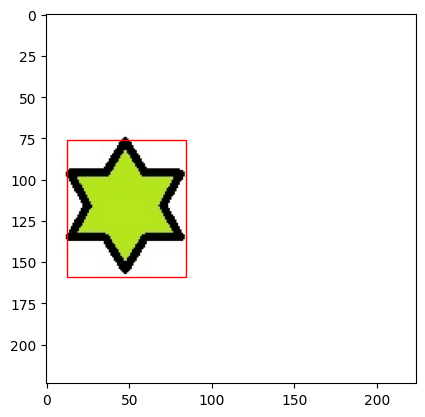

In [2]:
# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches

id = 10
img = images[id]
x_min, y_min, x_max, y_max = bboxes[id]

fig, ax = plt.subplots()
ax.imshow(img)

# Draw bounding box around the detected star
rect = patches.Rectangle((x_min, y_min), x_max-x_min,
                         y_max-y_min, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.show()

In [3]:
x = np.array(images)
y = np.array(bboxes)

print('x', x.shape)
print('y', y.shape)

x_train = x[:100]
y_train = y[:100]
x_test = x[100:]
y_test = y[100:]

x (112, 224, 224, 3)
y (112, 4)


In [5]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 1.7 MB/s  0:02:09m0:00:0100:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 1.7 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 3.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 1.8 MB/s  0:00:13m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [tensorflow]6 [tensorflow]


In [6]:
#Build model
from tensorflow import keras
from tensorflow.keras import layers

base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4)(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
#Train model
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - loss: 15989.9531 - mae: 105.7453 - val_loss: 13408.2627 - val_mae: 99.6869
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 12865.7109 - mae: 93.7857 - val_loss: 10155.0781 - val_mae: 85.3697
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 9515.1406 - mae: 80.0199 - val_loss: 6891.5234 - val_mae: 69.1026
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 6398.1465 - mae: 65.0718 - val_loss: 4180.5781 - val_mae: 53.7888
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 4046.2473 - mae: 52.2565 - val_loss: 2420.4382 - val_mae: 40.5597
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 2785.1699 - mae: 44.3818 - val_loss: 1668.7281 - val_mae: 34.8890
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 2221.1565 - mae: 39.7498 - val_loss: 1555.8903 - val_mae: 33.4444
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 2175.9639 - mae: 38.9060 - val_loss: 1610.2838 - val_mae: 33.3270
Epoch 9/3

In [8]:
#Evaluate model on Test set using average IoU
def compute_iou(pred, gt):
    xmin = max(pred[0], gt[0])
    ymin = max(pred[1], gt[1])
    xmax = min(pred[2], gt[2])
    ymax = min(pred[3], gt[3])

    inter_w = max(0, xmax - xmin)
    inter_h = max(0, ymax - ymin)
    intersection = inter_w * inter_h

    pred_area = (pred[2] - pred[0]) * (pred[3] - pred[1])
    gt_area = (gt[2] - gt[0]) * (gt[3] - gt[1])
    union = pred_area + gt_area - intersection

    return intersection / union if union > 0 else 0.0

y_pred = model.predict(x_test)
ious = [compute_iou(y_pred[i], y_test[i]) for i in range(len(y_test))]
print(f'Average IoU on test set: {np.mean(ious):.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
Average IoU on test set: 0.3681
